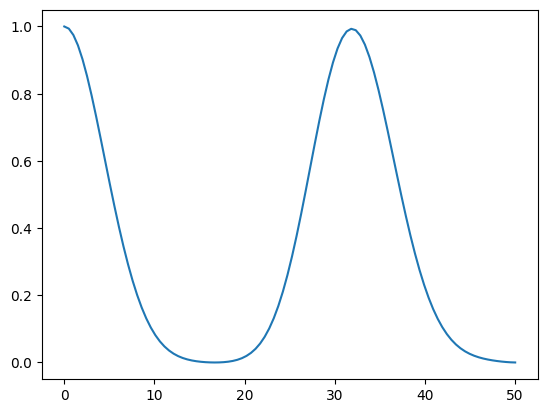

In [27]:
import qutip
import numpy as np


# Annihilation operator
a = np.array([[0.        , 1.        , 0.        , 0.        , 0.        , 0.        ],
            [0.        , 0.        , 1.41421356, 0.        , 0.        , 0.        ],
            [0.        , 0.        , 0.        , 1.73205081, 0.        , 0.        ],
            [0.        , 0.        , 0.        , 0.        , 2.        ,0.        ],
            [0.        , 0.        , 0.        , 0.        , 0.        , 2.23606798],
            [0.        , 0.        , 0.        , 0.        , 0.        ,0.        ]])
a = qutip.Qobj(a[:, :])

evals = np.array([ 0,  4,  8, 12, 16, 20])
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),dims=[[6] ,[6]])
)


diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

w_d = evals[1]-evals[0]
tot_time = 50
tlist = np.linspace(0, tot_time, tot_time*2)

amp = 0.05
def square_cos(t,*args):
    return  2*np.pi *amp * np.cos(w_d * 2*np.pi * t)

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos]]

result =  qutip.mesolve(
        H = H_with_drive,
        rho0=  qutip.basis(6,0),
        tlist = tlist,
        options=qutip.Options(store_states=True)
    )
import matplotlib.pyplot as plt
plt.plot(tlist,[np.square(state.full()[0][0].real) for state in result.states])

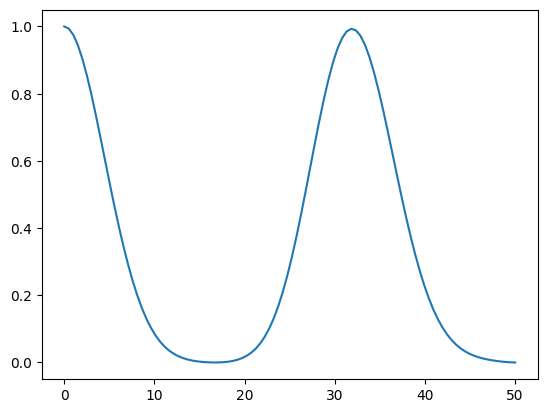

In [29]:
import os 
os.environ['JAX_JIT_PJIT_API_MERGE'] = '0'
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu')
from qiskit_dynamics.array import Array
Array.set_default_backend('jax')
import jax.numpy as jnp

def qobj_to_Array(matrix):
    if type(matrix) == qutip.qobj.Qobj:
        matrix = matrix.full()
    return Array(matrix)

static_hamiltonian = qobj_to_Array(diag_dressed_hamiltonian)
driven_operator =  qobj_to_Array(a+a.dag())

signal_sample_dt = 0.01 # Sample rate of the backend in ns.
from qiskit import pulse
with pulse.build(name="square") as square:
    pulse.play(pulse.Constant(duration = int(tot_time/signal_sample_dt), amp = amp * 2 * np.pi), pulse.DriveChannel(0))

from qiskit_dynamics import Solver
ham_solver =  Solver(
                hamiltonian_operators=[driven_operator],
                static_hamiltonian=static_hamiltonian,
                hamiltonian_channels=['d0'],
                channel_carrier_freqs={'d0': w_d},# * 2* np.pi},
                dt=signal_sample_dt
            )

result = ham_solver.solve(
    y0=jnp.zeros(6).at[0].set(1).reshape(-1, 1),
    t_span=[tlist[0], tlist[-1]],
    signals=square,
    method='jax_odeint',
    t_eval=tlist,
)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(tlist,[np.square(float(state[0][0].real)) for state in result.y],)
# ax.set_ylim(0.99999, 1) 